# Project 1: Image registration - Open Ended Problem

**Intensity-based registration using gradient ascent is a local optimizer. Furthermore the mutual information (MI)
landscape presents many local extrema. So, without an adequate initialization of the affine parameters, the algorithm
is likely to converge on a sub-optimal solution if the initial misalignment is significant.**

**Under this context, we want to explore the following research question: To what extent do hierarchical (Multi-
Resolution Pyramid) and analytical (Principal Axes Transformation) initialization strategies improve
the performance, defined by accuracy and efficiency, of affine registration for intra-modal (T1-T1) and
inter-modal (T1-T2) brain slices compared to a standard identity-initialization baseline?**

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("../code")
import registration_util as util
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter, zoom
import registration as reg
import pandas as pd
import time

def color_overlay(fixed_im, moving_im):
    fixed_norm = (fixed_im - fixed_im.min()) / (fixed_im.max() - fixed_im.min()) # Norm of fixed image
    moving_norm = (moving_im - moving_im.min()) / (moving_im.max() - moving_im.min()) # Norm of moving image
    
    overlay = np.zeros((fixed_im.shape[0], fixed_im.shape[1], 3))
    overlay[..., 0] = moving_norm  # Red
    overlay[..., 1] = fixed_norm   # Green
    overlay[..., 2] = moving_norm  # Blue
    
    return overlay

## Multi-resolution (pyramid) registration

To improve optimization robustness and avoid sub-optimal local maxima, we implemented a multi-resolution image pyramid. This framework allows the algorithm to compute global displacements at low resolutions before refining fine details at a full image resolution.
The key mechanics of the implemented framework are:

1. **Pyramid Construction:** At each pyramid level, the fixed and moving images are first smoothed using a **Gaussian filter** (with a standard deviation inversely proportional to the scale factor) and then resampled using **bilinear interpolation**. This downsampling acts as a low-pass filter, smoothing the non-convex Mutual Information ($MI$) landscape.

2. **Per-Level Optimization:**
   * **Initialization:** The lowest level (lowest resolution) begins with an identity transform vector.
   * **Internal Loop:** Each level executes an independent numerical **gradient ascent** loop, utilizing a central difference gradient approximation to maximize the similarity score until a stopping criterion is met.

3. **Inter-Level Parameter Propagation & Dynamic Scaling:**
   Once a level converges, its final transformation parameters initialize the next level. Because the translation parameters ($t_x, t_y$) are grid-dependent and defined in pixels, they must be dynamically scaled when transitioning to a higher resolution:
   
   $$t_{\text{new}} = t_{\text{old}} \times \frac{\text{scale}_{\text{new}}}{\text{scale}_{\text{old}}}$$

This cycle repeats sequentially until the algorithm finishes optimization on the full-resolution grid (scale 1.0), returning the final transformation matrix and registration metric.

In [2]:
def multi_resolution_registration(I_full, Im_full, method='mi', levels=[0.25, 0.5, 1.0], num_iter=[100,50,10], lr=[0.008, 0.004, 0.001], tolerance=1e-4):
    """
    Performs multi-resolution affine registration.
    
    levels: list of scaling factors (e.g., [0.25, 0.5, 1.0])
    method: 'mi' for Mutual Information or 'corr' for Correlation
    """

    # [phi, sx, sy, shx, shy, tx, ty]
    x = np.array([0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0])

    # We store how many iterations each level took
    iterations_per_level = []

    # Select the objective function based on the experiment
    if method == 'mi':
        reg_func = reg.affine_mi
    else:
        reg_func = reg.affine_corr

    current_scale = levels[0]

    for i, scale in enumerate(levels):
        # We calculate sigma based on the scale to avoid aliasing.
        sigma = (1.0/scale) - 1.0 if scale < 1.0 else 0

        I_blurred = gaussian_filter(I_full, sigma=sigma)
        Im_blurred = gaussian_filter(Im_full, sigma=sigma)

        # we downsample images for the current level
        I_low = zoom(I_blurred, scale)
        Im_low = zoom(Im_blurred, scale)

        # we adjust translation parameters to take into account the new scale
        if i > 0:
            scale_factor = scale / current_scale
            x[5]*=scale_factor # Update tx
            x[6]*=scale_factor # Update ty
        
        # we extract the specific hyperparameter for THIS specific level
        current_num_iter = num_iter[i] 
        current_lr = lr[i]
        current_scale = scale
        
        # we define the local objective function for this level
        fun = lambda x_iter: reg_func(I_low, Im_low, x_iter, return_transform=False)
        
        count=0
        prev_sim = -np.inf
        # we optimizie for the current level using the level-specific limit
        for k in range(current_num_iter):
            count=k+1
            # we compute gradient using your numerical differentiation
            g = reg.ngradient(fun, x)
            
            # we update parameters using the level-specific learning rate
            x += g*current_lr

            # early stopping if needed
            current_sim = fun(x)
            if abs(current_sim - prev_sim) < tolerance:
                break
            prev_sim = current_sim
        iterations_per_level.append(count)

    # we compute the final registration using full resolution and final parameters
    sim_final, Im_reg, _ = reg_func(I_full, Im_full, x, return_transform=True)
    
    return x, sim_final, Im_reg, iterations_per_level

### Defining the search space for the multi-resolution registration

To identify the optimal configuration for the multi-resolution framework, a comprehensive search was performed across the hyperparameter space. This search systematically evaluated combinations of:
* **Pyramid scale levels:** Testing different multi-resolution downsampling factors.
* **Iterations per level:** Optimizing the maximum steps at each individual resolution level.
* **Learning rates:** Fine-tuning localized step-sizes to prevent gradient divergence across different images.

The primary objective was to find the ideal "schedule" that maximized registration accuracy via **Mutual Information (MI)** while minimizing the normalized computational cost via **Full-Resolution Equivalents (FRE)**.

> **Execution Note:** Because evaluating the search space across the training image sets has a long execution time, the search loop code has been commented out below to preserve notebook performance. The high-performing, optimal parameter configurations determined by this optimization sweep are directly utilized in the final experiment blocks below.

In [ ]:
"""
# define the search space for the multi-resolution registration

schedules = [
    {
        "name": "3-Lvl: Baseline (flat)", 
        "levels": [0.25, 0.5, 1.0], 
        "iter": [50, 50, 50], 
        "lr": [0.002, 0.002, 0.002]
    },
    {
        "name": "3-Lvl: Aggressive bottom", 
        "levels": [0.25, 0.5, 1.0], 
        "iter": [150, 50, 10], 
        "lr": [0.008, 0.004, 0.001]
    },
    {
        "name": "3-Lvl: Moderate taper", 
        "levels": [0.25, 0.5, 1.0], 
        "iter": [100, 50, 20], 
        "lr": [0.004, 0.002, 0.001]
    },
    {
        "name": "3-Lvl: Fast cautious", 
        "levels": [0.25, 0.5, 1.0], 
        "iter": [100, 30, 10], 
        "lr": [0.002, 0.001, 0.001]
    },
    {
        "name": "3-Lvl: Ultra deep bottom", 
        "levels": [0.25, 0.5, 1.0], 
        "iter": [200, 20, 5], 
        "lr": [0.01, 0.002, 0.0005]
    },

    {
        "name": "4-Lvl: Deep start taper", 
        "levels": [0.125, 0.25, 0.5, 1.0], 
        "iter": [200, 100, 30, 10], 
        "lr": [0.01, 0.005, 0.002, 0.001]
    },
    {
        "name": "4-Lvl: Deep start fast", 
        "levels": [0.125, 0.25, 0.5, 1.0], 
        "iter": [150, 50, 20, 5], 
        "lr": [0.01, 0.004, 0.002, 0.001]
    },

    {
        "name": "2-Lvl: Half-to-Full (Skip 0.25)", 
        "levels": [0.5, 1.0], 
        "iter": [50, 20], 
        "lr": [0.004, 0.001]
    },
    {
        "name": "2-Lvl: Quarter-to-Full (Skip 0.5)", 
        "levels": [0.25, 1.0], 
        "iter": [100, 20], 
        "lr": [0.005, 0.001]
    },

    {
        "name": "3-Lvl: Fast cautious", 
        "levels": [0.25, 0.5, 1.0], 
        "iter": [100, 30, 10], 
        "lr": [0.002, 0.001, 0.001]
    },
    {
        "name": "3-Lvl: Ultra deep bottom", 
        "levels": [0.25, 0.5, 1.0], 
        "iter": [200, 20, 5], 
        "lr": [0.01, 0.002, 0.0005]
    },

    {
        "name": "4-Lvl: Smooth Gradient", 
        "levels": [0.25, 0.5, 0.75, 1.0], 
        "iter": [100, 50, 30, 10], 
        "lr": [0.005, 0.003, 0.002, 0.001]
    }
]

# Arrays to store results
results_t1 = []
results_t2 = []

# execute the targeted grid search

print("Starting parameter optimization search...\n")

for sched_idx, sched in enumerate(schedules):
    print(f"Testing Schedule {sched_idx + 1}/{len(schedules)}: {sched['name']}")
    
    sims_t1_temp, iters_t1_temp, times_t1_temp = [], [], []
    sims_t2_temp, iters_t2_temp, times_t2_temp = [], [], []
    
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        
        for i in range(3):
            for j in range(3):
                image_f = plt.imread(f'../data/image_data/{i+1}_{j+1}_t1.tif')
                image_d = plt.imread(f'../data/image_data/{i+1}_{j+1}_t1_d.tif')
                image_d_t2 = plt.imread(f'../data/image_data/{i+1}_{j+1}_t2.tif')

                # Run Intra-Modal (T1-T1)
                t0_t1 = time.perf_counter()
                _, sim_t1, _, it_t1 = multi_resolution_registration(
                    image_f, image_d, method='mi', levels=sched['levels'], 
                    num_iter=sched['iter'], lr=sched['lr']
                )
                t1_t1 = time.perf_counter()
                times_t1_temp.append(t1_t1 - t0_t1)
                
                # Run Inter-Modal (T1-T2)
                t0_t2 = time.perf_counter()
                _, sim_t2, _, it_t2 = multi_resolution_registration(
                    image_f, image_d_t2, method='mi', levels=sched['levels'], 
                    num_iter=sched['iter'], lr=sched['lr']
                )
                t1_t2 = time.perf_counter()
                times_t2_temp.append(t1_t2 - t0_t2)

                sims_t1_temp.append(sim_t1)
                sims_t2_temp.append(sim_t2)
                iters_t1_temp.append(it_t1)
                iters_t2_temp.append(it_t2)
        
        # Check if this schedule caused instability
        if len(w) > 0:
            print(f"  -> WARNING: Schedule {sched['name']} caused {len(w)} numeric warnings (likely gradient overflow).")
            # You might choose to penalize or skip this result entirely
            
    # Calculate FRE (Full-Resolution Equivalents) for this schedule
    weights = np.array(sched['levels'])**2
    
    # T1 FRE
    iters_t1_array = np.array(iters_t1_temp)
        
    # T2 FRE
    iters_t2_array = np.array(iters_t2_temp)

    # Calculate averages
    mean_sim_t1, mean_fre_t1, mean_time_t1 = np.mean(sims_t1_temp), np.mean(np.sum(iters_t1_array * weights, axis=1)), np.mean(times_t1_temp)
    mean_sim_t2, mean_fre_t2, mean_time_t2 = np.mean(sims_t2_temp), np.mean(np.sum(iters_t2_array * weights, axis=1)), np.mean(times_t2_temp)

    std_sim_t1, std_fre_t1, std_time_t1 = np.std(sims_t1_temp), np.std(np.sum(iters_t1_array * weights, axis=1)), np.std(times_t1_temp)
    std_sim_t2, std_fre_t2, std_time_t2 = np.std(sims_t2_temp), np.std(np.sum(iters_t2_array * weights, axis=1)), np.std(times_t2_temp)

    results_t1.append({"name": sched['name'], "mi": mean_sim_t1, "fre": mean_fre_t1})
    results_t2.append({"name": sched['name'], "mi": mean_sim_t2, "fre": mean_fre_t2})

    print(f"  -> T1-T1: MI={mean_sim_t1:.4f} ± {std_sim_t1:.4f}, FRE={mean_fre_t1:.2f} ± {std_fre_t1:.2f}, Time={mean_time_t1:.3f}s ± {std_time_t1:.3f}s")
    print(f"  -> T1-T2: MI={mean_sim_t2:.4f} ± {std_sim_t2:.4f}, FRE={mean_fre_t2:.2f} ± {std_fre_t2:.2f}, Time={mean_time_t2:.3f}s ± {std_time_t2:.3f}s\n")
# plot the performance graphs

def plot_pareto(results, title):
    # Extract data
    names = [r["name"] for r in results]
    mis = [r["mi"] for r in results]
    fres = [r["fre"] for r in results]
    
    plt.figure(figsize=(10, 6))
    
    # Note: For MI, higher is better. For FRE, lower is better.
    # Therefore, the "best" points are in the top-left of the graph.
    plt.scatter(fres, mis, color='blue', s=100)
    
    # Annotate points
    for i, name in enumerate(names):
        plt.annotate(name, (fres[i], mis[i]), xytext=(5, 5), textcoords='offset points')
        
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Computational Cost (FRE - Lower is Better)', fontsize=12)
    plt.ylabel('Accuracy (Mutual Information - Higher is Better)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Draw a mock Pareto front line (conceptual visualization)
    # Sort by FRE ascending to draw the line
    sorted_indices = np.argsort(fres)
    fres_sorted = np.array(fres)[sorted_indices]
    mis_sorted = np.array(mis)[sorted_indices]
    
    pareto_fres = [fres_sorted[0]]
    pareto_mis = [mis_sorted[0]]
    current_max_mi = mis_sorted[0]
    
    for i in range(1, len(fres_sorted)):
        if mis_sorted[i] > current_max_mi:
            pareto_fres.append(fres_sorted[i])
            pareto_mis.append(mis_sorted[i])
            current_max_mi = mis_sorted[i]
            
    plt.plot(pareto_fres, pareto_mis, 'r--', alpha=0.5, label="Pareto Frontier")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Generate the two plots
plot_pareto(results_t1, "Pareto Frontier: Intra-Modal (T1-T1) Optimization")
plot_pareto(results_t2, "Pareto Frontier: Inter-Modal (T1-T2) Optimization")
"""

### Optimized pyramid

Based on the results of our hyperparameter parameter search, we established two distinct execution schedules adapated to the unique landscape complexities of the intra-modal (T1-T1) and inter-modal (T1-T2) registration tasks.

* **Intra-Modal Schedule (`sched_t1`):** Because the mono-modal T1-T1 intensity relationship is strictly linear and highly convex, the optimizer smoothly converges toward the global maximum with a modest iteration number.
* **Inter-Modal Schedule (`sched_t2`):** Implements an aggressive learning rate ($\mu = 0.01$) paired with an extended iteration number (200 steps) at the lowest scale (0.25). On the other hand, at full resolution (1.0), the learning rate is diminished ($\mu = 0.0005$) and capped at 5 iterations to perform fine tuning without risking gradient divergence or overshooting the global peak.

In [3]:
sched_t1 = {
    "name": "T1-T1", 
    "levels": [0.25, 0.5, 1.0], 
    "iter": [100, 30, 10], 
    "lr": [0.002, 0.001, 0.001]
}

sched_t2 = {
    "name": "T1-T2", 
    "levels": [0.25, 0.5, 1.0], 
    "iter": [200, 20, 5], 
    "lr": [0.01, 0.002, 0.0005]
}

sims_t1_temp, iters_t1_temp, times_t1_temp = [], [], []
sims_t2_temp, iters_t2_temp, times_t2_temp = [], [], []

for i in range(3):
    for j in range(3):
        image_f = plt.imread(f'../data/image_data/{i+1}_{j+1}_t1.tif')
        image_d = plt.imread(f'../data/image_data/{i+1}_{j+1}_t1_d.tif')
        image_d_t2 = plt.imread(f'../data/image_data/{i+1}_{j+1}_t2.tif')

        # Run Intra-Modal (T1-T1)
        t0_t1 = time.perf_counter()
        _, sim_t1, _, it_t1 = multi_resolution_registration(
            image_f, image_d, method='mi', levels=sched_t1['levels'], 
            num_iter=sched_t1['iter'], lr=sched_t1['lr']
        )
        t1_t1 = time.perf_counter()
        times_t1_temp.append(t1_t1 - t0_t1)
        
        # Run Inter-Modal (T1-T2)
        t0_t2 = time.perf_counter()
        _, sim_t2, _, it_t2 = multi_resolution_registration(
            image_f, image_d_t2, method='mi', levels=sched_t2['levels'], 
            num_iter=sched_t2['iter'], lr=sched_t2['lr']
        )
        t1_t2 = time.perf_counter()
        times_t2_temp.append(t1_t2 - t0_t2)

        sims_t1_temp.append(sim_t1)
        sims_t2_temp.append(sim_t2)
        iters_t1_temp.append(it_t1)
        iters_t2_temp.append(it_t2)

    
# Calculate FRE (Full-Resolution Equivalents) for this image
weights_t1 = np.array(sched_t1['levels'])**2
weights_t2 = np.array(sched_t2['levels'])**2

# T1 FRE
iters_t1_array = np.array(iters_t1_temp)

# T2 FRE
iters_t2_array = np.array(iters_t2_temp)

# Calculate averages
mean_sim_t1, mean_fre_t1, mean_time_t1 = np.mean(sims_t1_temp), np.mean(np.sum(iters_t1_array*weights_t1, axis=1)), np.mean(times_t1_temp)
mean_sim_t2, mean_fre_t2, mean_time_t2 = np.mean(sims_t2_temp), np.mean(np.sum(iters_t2_array*weights_t2, axis=1)), np.mean(times_t2_temp)

std_sim_t1, std_fre_t1, std_time_t1 = np.std(sims_t1_temp), np.std(np.sum(iters_t1_array*weights_t1, axis=1)), np.std(times_t1_temp)
std_sim_t2, std_fre_t2, std_time_t2 = np.std(sims_t2_temp), np.std(np.sum(iters_t2_array*weights_t2, axis=1)), np.std(times_t2_temp)


print(f" -> T1-T1: MI={mean_sim_t1:.4f} ± {std_sim_t1:.4f}, FRE={mean_fre_t1:.2f} ± {std_fre_t1:.2f}, Time={mean_time_t1:.3f}s ± {std_time_t1:.3f}s")
print(f" -> T1-T2: MI={mean_sim_t2:.4f} ± {std_sim_t2:.4f}, FRE={mean_fre_t2:.2f} ± {std_fre_t2:.2f}, Time={mean_time_t2:.3f}s ± {std_time_t2:.3f}s\n")

 -> T1-T1: MI=0.6699 ± 0.1219, FRE=22.49 ± 3.56, Time=164.225s ± 44.702s
 -> T1-T2: MI=0.6204 ± 0.0357, FRE=22.24 ± 0.75, Time=150.543s ± 12.475s



## Principal Axes Transformation (PAT)

PAT aligns two images by computing the intensity-weighted **centre of mass** and the **inertia matrix** for each image, then finding the rotation that maps one set of principal axes onto the other.

Pixel intensities are treated as mass weights. The intensity-weighted mean position is:

$$c_x = \frac{\sum_{r,c} I(r,c)\cdot c}{\sum_{r,c} I(r,c)}, \qquad c_y = \frac{\sum_{r,c} I(r,c)\cdot r}{\sum_{r,c} I(r,c)}$$

where $c$ is the **column** index (the $x$ coordinate) and $r$ is the **row** index (the $y$ coordinate).


In [4]:
def compute_centre_of_mass(I):
    """
    Compute the intensity-weighted centre of mass of a 2D image.

    Returns
    -------
    com : ndarray, shape (2,)
        [cx, cy] where cx is the weighted mean column index
        and cy is the weighted mean row index.
    """
    rows, cols = np.indices(I.shape)   # rows[r,c]=r,  cols[r,c]=c
    total = I.sum()
    cx = (I * cols).sum() / total
    cy = (I * rows).sum() / total
    return np.array([cx, cy])

The **2×2 inertia matrix** encodes how the image mass is distributed around the centre of mass:

$$\mu_{20} = \frac{\sum I(r,c)(c-c_x)^2}{\sum I}, \quad
  \mu_{02} = \frac{\sum I(r,c)(r-c_y)^2}{\sum I}, \quad
  \mu_{11} = \frac{\sum I(r,c)(c-c_x)(r-c_y)}{\sum I}$$

$$M = \begin{pmatrix} \mu_{20} & \mu_{11} \\ \mu_{11} & \mu_{02} \end{pmatrix}$$

In [5]:
def compute_second_moment_matrix(I, com):
    """
    Compute the 2x2 intensity-weighted second moment (inertia) matrix.

    Parameters
    ----------
    I   : 2D ndarray — image
    com : ndarray shape (2,) — [cx, cy] from compute_centre_of_mass

    Returns
    -------
    M : ndarray, shape (2, 2)
    """
    cx, cy = com
    rows, cols = np.indices(I.shape)
    total = I.sum()

    dx = cols - cx   # column displacement  (x direction)
    dy = rows - cy   # row displacement     (y direction)

    mu20 = (I * dx**2).sum() / total
    mu02 = (I * dy**2).sum() / total
    mu11 = (I * dx * dy).sum() / total

    return np.array([[mu20, mu11],
                     [mu11, mu02]])

The **principal axes** are the eigenvectors of the inertia matrix $M$.  The eigenvector corresponding to the **largest** eigenvalue points along the direction of greatest mass spread (the major axis).

In [6]:
def compute_principal_axes(M):
    """
    Compute principal axes from a 2x2 second moment matrix.

    Returns
    -------
    S : ndarray, shape (2, 2)
        Columns are eigenvectors sorted by descending eigenvalue.
        S[:, 0] is the major (principal) axis.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(M)
    # eigh returns ascending order — reverse to get descending
    idx = np.argsort(eigenvalues)[::-1]
    return eigenvectors[:, idx]

Given the principal axes matrices $S_I$ (fixed) and $S_J$ (moving), the rotation that maps the moving axes onto the fixed axes is:

$$R = S_I \, S_J^\top$$

The corresponding translation centres both images after rotation:

$$\mathbf{t} = \mathbf{c}_I - R\,\mathbf{c}_J$$

This defines a **forward** mapping $\mathbf{x}_I = R\,\mathbf{x}_J + \mathbf{t}$.

`image_transform` uses **inverse mapping**.  The **inverse** of the forward transform is:

$$T_h = \begin{pmatrix} R^\top & \mathbf{c}_J - R^\top\mathbf{c}_I \\ \mathbf{0}^\top & 1 \end{pmatrix}$$

Because eigenvectors are defined up to a sign, a 180° ambiguity exists. Both $S$ and $-S$ are valid; we resolve it by trying both orientations and keeping the one with higher NCC.

In [7]:
def principal_axes_transform(I, J):
    """
    Compute the PAT homogeneous matrix that registers moving image J to fixed image I.

    Returns
    -------
    Th_best : ndarray, shape (3, 3)
        Homogeneous transformation matrix for use with image_transform.
        Maps fixed-image coordinates to moving-image coordinates (inverse mapping).
    """
    # -- centres of mass --
    com_I = compute_centre_of_mass(I)
    com_J = compute_centre_of_mass(J)

    # -- second moment matrices --
    M_I = compute_second_moment_matrix(I, com_I)
    M_J = compute_second_moment_matrix(J, com_J)

    # -- principal axes --
    S_I = compute_principal_axes(M_I)
    S_J = compute_principal_axes(M_J)

    # -- rotation that maps J's axes onto I's axes --
    R = S_I @ S_J.T

    # report rotation angle
    theta = np.arctan2(R[1, 0], R[0, 0])
    #print(f'Rotation angle: {theta:.4f} rad  ({np.degrees(theta):.2f} deg)')

    def build_Th(R_mat):
        # inverse mapping: fixed -> moving
        R_inv = R_mat.T
        t_inv = com_J - R_inv @ com_I
        return util.t2h(R_inv, t_inv)

    Th      = build_Th(R)
    Th_flip = build_Th(-R)   # 180-degree flipped solution

    J_t,      _ = reg.image_transform(J, Th)
    J_t_flip, _ = reg.image_transform(J, Th_flip)

    ncc      = reg.correlation(I, J_t)
    ncc_flip = reg.correlation(I, J_t_flip)

    if ncc >= ncc_flip:
        #print(f'Selected: original orientation  (NCC={ncc:.4f} vs flipped NCC={ncc_flip:.4f})')
        return Th
    else:
        theta_flip = np.arctan2(-R[1, 0], -R[0, 0])
        #print(f'Selected: flipped orientation   (NCC={ncc_flip:.4f} vs original NCC={ncc:.4f})')
        #print(f'Adjusted rotation angle: {theta_flip:.4f} rad  ({np.degrees(theta_flip):.2f} deg)')
        return Th_flip

### PAT Tests

In [13]:
# Shared constants
N_ITERATIONS  = 50
LEARNING_RATE = 1e-3
PATIENTS = [1, 2, 3]
SLICES = [1, 2, 3]
DATA_DIR = '../data/'
SCALING  = 100

We first build the dataset of image pairs. Eighteen pairs total: for each patient (1–3) and slice (1–3), one intra-modal T1→T1d pair and one inter-modal T1→T2 pair. The fixed image is always the T1 scan.

In [17]:
def load_image(patient_id, slice_id, sequence):
    """Load a .tif image and return it as a float64 array."""
    path = f'{DATA_DIR}image_data/{patient_id}_{slice_id}_{sequence}.tif'
    return plt.imread(path).astype(np.float64)

all_pairs = []
for patient_id in PATIENTS:
    for slice_id in SLICES:
        fixed = load_image(patient_id, slice_id, 't1')

        # T1 -> T1d (intra-modal)
        all_pairs.append({
            'pair_id':    f'P{patient_id}_S{slice_id}_T1T1d',
            'patient_id': patient_id,
            'slice_id':   slice_id,
            'modality':   'T1-T1d',
            'fixed':      fixed,
            'moving':     load_image(patient_id, slice_id, 't1_d'),
        })

        # T1 -> T2 (inter-modal)
        all_pairs.append({
            'pair_id':    f'P{patient_id}_S{slice_id}_T1T2',
            'patient_id': patient_id,
            'slice_id':   slice_id,
            'modality':   'T1-T2',
            'fixed':      fixed,
            'moving':     load_image(patient_id, slice_id, 't2'),
        })

Then, for each of the 18 pairs we run all three strategies and record NCC, MI, and convergence criterion. The tested strategies are:

- Identity Initialization
- PAT standalone
- PAT initialization + Gradient Ascend

In [ ]:
def convergence_iter(history, threshold=1e-4):
    """First iteration where |history[i]-history[i-1]| < threshold, else N_ITERATIONS."""
    for i in range(1, len(history)):
        if abs(history[i] - history[i - 1]) < threshold:
            return i
    return len(history)


def run_all_strategies(pairs, n_iterations, learning_rate):
    records     = []
    images_dict = {}

    for pair in pairs:
        pair_id    = pair['pair_id']
        patient_id = pair['patient_id']
        slice_id   = pair['slice_id']
        modality   = pair['modality']
        fixed      = pair['fixed']
        moving     = pair['moving']

        """
        if modality == 'T1-T1d':
            sim_fn = lambda x, f=fixed, m=moving: reg.rigid_corr(f, m, x, return_transform=False)
        else:
            sim_fn = lambda x, f=fixed, m=moving: rigid_mi(f, m, x)
        """

        sim_fn = lambda x, f=fixed, m=moving: reg.affine_mi(f, m, x, return_transform=False)

        ncc_before = reg.correlation(fixed, moving)
        mi_before  = reg.mutual_information(reg.joint_histogram(fixed, moving))

        print(f'\n=== {pair_id} ({modality}) ===')

        # -- Strategy A: identity init --
        print('Strategy A:')
        start_time = time.perf_counter()
        x_init_a        = np.array([0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0])
        x_opt_a, hist_a = reg.gradient_ascent_registration(
            fixed, moving, x_init_a, sim_fn, n_iterations, learning_rate)
        Th_a            = reg.params_to_Th(x_opt_a)
        J_reg_a, _      = reg.image_transform(moving, Th_a)
        ncc_a           = reg.correlation(fixed, J_reg_a)
        mi_a            = reg.mutual_information(reg.joint_histogram(fixed, J_reg_a))
        conv_a          = convergence_iter(hist_a)
        images_dict[(pair_id, 'A')] = J_reg_a
        end_time = time.perf_counter()
        elapsed_time_A = end_time - start_time

        # -- Strategy B: PAT standalone --
        print('Strategy B:')
        start_time = time.perf_counter()
        Th_b            = principal_axes_transform(fixed, moving)
        J_reg_b, _      = reg.image_transform(moving, Th_b)
        ncc_b           = reg.correlation(fixed, J_reg_b)
        mi_b            = reg.mutual_information(reg.joint_histogram(fixed, J_reg_b))
        angle_b         = np.arctan2(Th_b[1, 0], Th_b[0, 0])
        tx_b            = Th_b[0, 2] # / SCALING
        ty_b            = Th_b[1, 2] # / SCALING
        images_dict[(pair_id, 'B')] = J_reg_b
        end_time = time.perf_counter()
        elapsed_time_B = end_time - start_time

        # -- Strategy C: PAT init + gradient ascent --
        print('Strategy C:')
        start_time = time.perf_counter()
        x_init_c        = np.array([angle_b, 1.0, 1.0, 0.0, 0.0, tx_b, ty_b])
        x_opt_c, hist_c = reg.gradient_ascent_registration(
            fixed, moving, x_init_c, sim_fn, n_iterations, learning_rate)
        Th_c            = reg.params_to_Th(x_opt_c)
        J_reg_c, _      = reg.image_transform(moving, Th_c)
        ncc_c           = reg.correlation(fixed, J_reg_c)
        mi_c            = reg.mutual_information(reg.joint_histogram(fixed, J_reg_c))
        conv_c          = convergence_iter(hist_c)
        images_dict[(pair_id, 'C')] = J_reg_c
        end_time = time.perf_counter()
        elapsed_time_C = end_time - start_time

        for strat, ncc_val, mi_val, conv_val, e_time in [
            ('A', ncc_a, mi_a, conv_a, elapsed_time_A),
            ('B', ncc_b, mi_b, 0, elapsed_time_B),
            ('C', ncc_c, mi_c, conv_c, elapsed_time_C),
        ]:
            records.append({
                'pair_id':                pair_id,
                'patient_id':             patient_id,
                'slice_id':               slice_id,
                'modality':               modality,
                'strategy':               strat,
                'ncc_before':             ncc_before,
                'ncc_after':              ncc_val,
                'mi_before':              mi_before,
                'mi_after':               mi_val,
                'converged_at_iteration': conv_val,
                'time':                   e_time,
            })

        #print(f'Done: {pair_id} | NCC  A={ncc_a:.4f}  B={ncc_b:.4f}  C={ncc_c:.4f}')

    return pd.DataFrame(records), images_dict

results, images_dict = run_all_strategies(all_pairs, N_ITERATIONS, LEARNING_RATE)

results_t1t1d = results[results.modality == 'T1-T1d']
results_t1t2  = results[results.modality == 'T1-T2']


def summary_table(df, modality_label):
    rows = []
    for s in ['A', 'B', 'C']:
        dg = df[df.strategy == s]
        rows.append({
            'Strategy':               s,
            'NCC after (mean±std)':   f'{dg["ncc_after"].mean():.4f} ± {dg["ncc_after"].std():.4f}',
            'MI after (mean±std)':    f'{dg["mi_after"].mean():.4f} ± {dg["mi_after"].std():.4f}',
            'Converged at (mean±std)': f'{dg["converged_at_iteration"].mean():.1f} ± {dg["converged_at_iteration"].std():.1f}',
            'Time (mean±std)': f'{dg["time"].mean():.1f} ± {dg["time"].std():.1f}',

        })
    tbl = pd.DataFrame(rows)
    print(f'{modality_label}  (n = {len(df) // 3} pairs per strategy)')
    display(tbl)

In [20]:
summary_table(results_t1t1d, 'T1-T1d (intra-modal)')

T1-T1d (intra-modal)  (n = 9 pairs per strategy)


,Strategy,NCC after (mean±std),MI after (mean±std),Converged at (mean±std),Time (mean±std)
0,A,0.8367 ± 0.0725,0.5937 ± 0.0721,51.0 ± 0.0,431.6 ± 36.7
1,B,0.8634 ± 0.0817,0.7175 ± 0.2939,0.0 ± 0.0,0.6 ± 0.1
2,C,0.8358 ± 0.0961,0.6032 ± 0.0855,42.1 ± 17.7,363.5 ± 151.7


In [19]:
summary_table(results_t1t2, 'T1-T2 (inter-modal)')

T1-T2 (inter-modal)  (n = 9 pairs per strategy)


,Strategy,NCC after (mean±std),MI after (mean±std),Converged at (mean±std),Time (mean±std)
0,A,0.7837 ± 0.0622,0.5860 ± 0.0414,34.1 ± 17.4,301.5 ± 160.6
1,B,0.8479 ± 0.0184,0.6497 ± 0.0407,0.0 ± 0.0,0.6 ± 0.0
2,C,0.8140 ± 0.0359,0.6122 ± 0.0289,51.0 ± 0.0,437.4 ± 34.5


### PAT + Multi-Resolution Pyramid Optimization

This section introduces the last evaluation pipeline of the project: the **Hybrid PAT + Pyramid** strategy. By calculating the analytical PAT before building the image pyramid, we provide the multi-resolution framework with a refined global initialization. 

The optimized schedules derived for this hybrid approach are:

* **Massive Iteration Reduction:** Compared to our previous identity-initialized pyramid, the iteration budget at the lowest scale ($0.25$) has been reduced from 100 down to **30 iterations** for T1-T1, and from 200 down to just **15 iterations** for T1-T2. Because PAT handles the massive initial global translation and rotation analytically, the local optimizer starts close to the global maximum and requires very few iterative steps to adjust.
* **Accelerated Step Sizes:** Since the initial alignment is already close, we can use slightly higher learning rates at the lower scales ($\mu = 0.005$ and $\mu = 0.008$) without risking gradient divergence.
* **Minimal Fine Polishing:** At full resolution ($1.0$), the iterations are strictly limited at 10 and 5 steps respectively. This achieves the precision of intensity-driven Mutual Information while keeping the overall **Full-Resolution Equivalent (FRE)** computational cost exceptionally low.

In [8]:
def multi_resolution_registration_pat(I_full, Im_full, method='mi', 
                                      levels=[0.25, 0.5, 1.0], 
                                      num_iter=[50, 20, 10],   
                                      lr=[0.005, 0.002, 0.001], 
                                      tolerance=1e-3):
    
    # We first run PAT to get the initial rigid alignment matrix (Th)
    Th_pat = principal_axes_transform(I_full, Im_full)
    
    # we then xtract rotation angle (phi) and translations (tx, ty) from the 3x3 matrix
    phi = np.arctan2(Th_pat[1, 0], Th_pat[0, 0])
    tx_full = Th_pat[0, 2]
    ty_full = Th_pat[1, 2]
    
    # We initialize the affine parameter array: [phi, sx, sy, shx, shy, tx, ty]
    # here it is important to scale the full-resolution translations to match the starting level
    start_scale = levels[0]
    x = np.array([phi, 1.0, 1.0, 0.0, 0.0, tx_full * start_scale, ty_full * start_scale])

    iterations_per_level = []

    # we select the objective function based on the experiment
    if method == 'mi':
        reg_func = reg.affine_mi
    else:
        reg_func = reg.affine_corr

    current_scale = levels[0]

    for i, scale in enumerate(levels):
        # We calculate sigma based on the scale to avoid aliasing.
        sigma = (1.0/scale) - 1.0 if scale < 1.0 else 0

        I_blurred = gaussian_filter(I_full, sigma=sigma)
        Im_blurred = gaussian_filter(Im_full, sigma=sigma)

        # we downsample images for the current level
        I_low = zoom(I_blurred, scale)
        Im_low = zoom(Im_blurred, scale)

        # we adjust translation parameters to take into account the new scale
        if i > 0:
            scale_factor = scale / current_scale
            x[5]*=scale_factor # Update tx
            x[6]*=scale_factor # Update ty
        
        # we extract the specific hyperparameter for THIS specific level
        current_num_iter = num_iter[i] 
        current_lr = lr[i]
        current_scale = scale
        
        # we define the local objective function for this level
        fun = lambda x_iter: reg_func(I_low, Im_low, x_iter, return_transform=False)
        
        count=0
        prev_sim = -np.inf
        # we optimizie for the current level using the level-specific limit
        for k in range(current_num_iter):
            count=k+1
            # we compute gradient using your numerical differentiation
            g = reg.ngradient(fun, x)
            
            # we update parameters using the level-specific learning rate
            x += g*current_lr

            # early stopping if needed
            current_sim = fun(x)
            if abs(current_sim - prev_sim) < tolerance:
                break
            prev_sim = current_sim
        iterations_per_level.append(count)

    # we compute the final registration using full resolution and final parameters
    sim_final, Im_reg, _ = reg_func(I_full, Im_full, x, return_transform=True)
    
    return x, sim_final, Im_reg, iterations_per_level


In [9]:
sched_t1 = {
    "name": "T1-T1", 
    "levels": [0.25, 0.5, 1.0], 
    "iter": [30, 20, 10], 
    "lr": [0.005, 0.002, 0.001]
}

sched_t2 = {
    "name": "T1-T2", 
    "levels": [0.25, 0.5, 1.0], 
    "iter": [15, 10, 5], 
    "lr": [0.008, 0.002, 0.001]
}

sims_t1_temp, iters_t1_temp, times_t1_temp = [], [], []
sims_t2_temp, iters_t2_temp, times_t2_temp = [], [], []

for i in range(3):
    for j in range(3):
        image_f = plt.imread(f'../data/image_data/{i+1}_{j+1}_t1.tif')
        image_d_t1 = plt.imread(f'../data/image_data/{i+1}_{j+1}_t1_d.tif')
        image_d_t2 = plt.imread(f'../data/image_data/{i+1}_{j+1}_t2.tif')

        # Run Intra-Modal (T1-T1)
        t0_t1 = time.perf_counter()
        _, sim_t1, _, it_t1 = multi_resolution_registration_pat(
            image_f, image_d_t1, method='mi', 
            levels=sched_t1['levels'], num_iter=sched_t1['iter'], 
            lr=sched_t1['lr'], tolerance=1e-3
        )
        t1_t1 = time.perf_counter()
        times_t1_temp.append(t1_t1 - t0_t1)
        
        # Run Inter-Modal (T1-T2)
        t0_t2 = time.perf_counter()
        _, sim_t2, _, it_t2 = multi_resolution_registration_pat(
            image_f, image_d_t2, method='mi', 
            levels=sched_t2['levels'], num_iter=sched_t2['iter'], 
            lr=sched_t2['lr'], tolerance=1e-3
        )
        t1_t2 = time.perf_counter()
        times_t2_temp.append(t1_t2 - t0_t2)

        sims_t1_temp.append(sim_t1)
        sims_t2_temp.append(sim_t2)
        iters_t1_temp.append(it_t1)
        iters_t2_temp.append(it_t2)


# Calculate Dataset Averages
weights_t1 = np.array(sched_t1['levels'])**2
weights_t2 = np.array(sched_t2['levels'])**2

# T1 FRE
iters_t1_array = np.array(iters_t1_temp)

# T2 FRE
iters_t2_array = np.array(iters_t2_temp)

# Calculate averages
mean_sim_t1, mean_fre_t1, mean_time_t1 = np.mean(sims_t1_temp), np.mean(np.sum(iters_t1_array*weights_t1, axis=1)), np.mean(times_t1_temp)
mean_sim_t2, mean_fre_t2, mean_time_t2 = np.mean(sims_t2_temp), np.mean(np.sum(iters_t2_array*weights_t2, axis=1)), np.mean(times_t2_temp)

std_sim_t1, std_fre_t1, std_time_t1 = np.std(sims_t1_temp), np.std(np.sum(iters_t1_array*weights_t1, axis=1)), np.std(times_t1_temp)
std_sim_t2, std_fre_t2, std_time_t2 = np.std(sims_t2_temp), np.std(np.sum(iters_t2_array*weights_t2, axis=1)), np.std(times_t2_temp)

print(f" -> T1-T1: MI={mean_sim_t1:.4f} ± {std_sim_t1:.4f}, FRE={mean_fre_t1:.2f} ± {std_fre_t1:.2f}, Time={mean_time_t1:.3f}s ± {std_time_t1:.3f}s")
print(f" -> T1-T2: MI={mean_sim_t2:.4f} ± {std_sim_t2:.4f}, FRE={mean_fre_t2:.2f} ± {std_fre_t2:.2f}, Time={mean_time_t2:.3f}s ± {std_time_t2:.3f}s\n")

 -> T1-T1: MI=0.6613 ± 0.0624, FRE=13.76 ± 3.11, Time=119.529s ± 28.460s
 -> T1-T2: MI=0.6434 ± 0.0454, FRE=8.39 ± 0.09, Time=74.789s ± 7.443s



## Strategies Comparison: single-slice evaluation

This final analytical section aggregates all five developed algorithmic strategies to conduct a side-by-side comparative evaluation on a single representative image slice.

#### Evaluated Structural Pipelines:

* **Initial State:** The unregistered, raw distorted image pair establishing the baseline geometric displacement.
* **Baseline:** Gradient Ascent (GA) initialized with the identity transformation.
* **Optimal Multi-Resolution Pyramid:** Hierarchical GA using modality-specific optimized schedules (deter-
mined via grid search)
* **PAT:** The closed-form Principal Axes Transformation with no iterative refinement.
* **PAT + Gradient Ascent:** PAT initialization followed by a standard full-resolution GA optimization
* **PAT + Pyramid:** PAT initialization followed by the optimized multi-resolution pyramid refinement.

The resulting color represents the fixed reference scan to the green channel and the registered moving scan to the red and blue channels, providing a clear visual diagnostic: full grayscale visualization indicates successful spatial registration, while chromatic fringing identifies registration errors.

In [ ]:
i, j = 2, 1
fixed = plt.imread(f'../data/image_data/{i+1}_{j+1}_t1.tif')
moving = plt.imread(f'../data/image_data/{i+1}_{j+1}_t1_d.tif')
moving_t2 = plt.imread(f'../data/image_data/{i+1}_{j+1}_t2.tif')

sched_t1_PAT = {
    "name": " ", 
    "levels": [0.25, 0.5, 1.0], 
    "iter": [30, 20, 10], 
    "lr": [0.005, 0.002, 0.001]
}

sched_t2_PAT = {
    "name": " ", 
    "levels": [0.25, 0.5, 1.0], 
    "iter": [15, 10, 5], 
    "lr": [0.008, 0.002, 0.001]
}

sched_t1 = {
    "name": "T1-T1", 
    "levels": [0.25, 0.5, 1.0], 
    "iter": [100, 30, 10], 
    "lr": [0.002, 0.001, 0.001]
}

sched_t2 = {
    "name": "T1-T2", 
    "levels": [0.25, 0.5, 1.0], 
    "iter": [200, 20, 5], 
    "lr": [0.01, 0.002, 0.0005]
}

# Run T1-T1 Registration with optimized pyramid
_, sim_t1, reg_t1_pyramid, _ = multi_resolution_registration(
    fixed, moving, method='mi', 
    levels=sched_t1['levels'], num_iter=sched_t1['iter'], 
    lr=sched_t1['lr'], tolerance=1e-3
)

# Run T1-T2 Registration with optimized pyramid
_, sim_t2, reg_t2_pyramid, _ = multi_resolution_registration(
    fixed, moving_t2, method='mi', 
    levels=sched_t2['levels'], num_iter=sched_t2['iter'], 
    lr=sched_t2['lr'], tolerance=1e-3
)

# Run T1-T2 Registration with pyramid + PAT
_, sim_t1, reg_t1_pyramid_pat, _ = multi_resolution_registration_pat(
    fixed, moving, method='mi', 
    levels=sched_t1['levels'], num_iter=sched_t1['iter'], 
    lr=sched_t1['lr'], tolerance=1e-3
)

# Run T1-T2 Registration pyramid + PAT
_, sim_t2, reg_t2_pyramid_pat, _ = multi_resolution_registration_pat(
    fixed, moving_t2, method='mi', 
    levels=sched_t2['levels'], num_iter=sched_t2['iter'], 
    lr=sched_t2['lr'], tolerance=1e-3
)

n_iterations = 50
learning_rate = 1e-3

## T1-T1 REGISTRATION USING PAT
sim_fn = lambda x, f=fixed, m=moving: reg.affine_mi(f, m, x, return_transform=False)

# identity init
x_init_a        = np.array([0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0])
x_opt_a, hist_a = reg.gradient_ascent_registration(
    fixed, moving, x_init_a, sim_fn, n_iterations, learning_rate)
Th_a            = reg.params_to_Th(x_opt_a)
reg_t1_baseline, _      = reg.image_transform(moving, Th_a)

# PAT standalone
Th_b            = principal_axes_transform(fixed, moving)
reg_t1_pat, _      = reg.image_transform(moving, Th_b)
angle_b         = np.arctan2(Th_b[1, 0], Th_b[0, 0])
tx_b            = Th_b[0, 2] # / SCALING
ty_b            = Th_b[1, 2] # / SCALING

# PAT init + gradient ascent 
x_init_c        = np.array([angle_b, 1.0, 1.0, 0.0, 0.0, tx_b, ty_b])
x_opt_c, hist_c = reg.gradient_ascent_registration(
    fixed, moving, x_init_c, sim_fn, n_iterations, learning_rate)
Th_c            = reg.params_to_Th(x_opt_c)
reg_t1_pat_ga, _      = reg.image_transform(moving, Th_c)


## T1-T2 REGISTRATION USING PAT
sim_fn = lambda x, f=fixed, m=moving_t2: reg.affine_mi(f, m, x, return_transform=False)

# identity init
x_init_a        = np.array([0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0])
x_opt_a, hist_a = reg.gradient_ascent_registration(
    fixed, moving, x_init_a, sim_fn, n_iterations, learning_rate)
Th_a            = reg.params_to_Th(x_opt_a)
reg_t2_baseline, _      = reg.image_transform(moving, Th_a)

# PAT standalone
Th_b            = principal_axes_transform(fixed, moving)
reg_t2_pat, _      = reg.image_transform(moving, Th_b)
angle_b         = np.arctan2(Th_b[1, 0], Th_b[0, 0])
tx_b            = Th_b[0, 2] # / SCALING
ty_b            = Th_b[1, 2] # / SCALING

# PAT init + gradient ascent 
x_init_c        = np.array([angle_b, 1.0, 1.0, 0.0, 0.0, tx_b, ty_b])
x_opt_c, hist_c = reg.gradient_ascent_registration(
    fixed, moving, x_init_c, sim_fn, n_iterations, learning_rate)
Th_c            = reg.params_to_Th(x_opt_c)
reg_t2_pat_ga, _      = reg.image_transform(moving, Th_c)

results_t1 = [reg_t1_baseline, reg_t1_pyramid, reg_t1_pat, reg_t1_pat_ga, reg_t1_pyramid_pat]
results_t2 = [reg_t2_baseline, reg_t2_pyramid, reg_t2_pat, reg_t2_pat_ga, reg_t2_pyramid_pat]

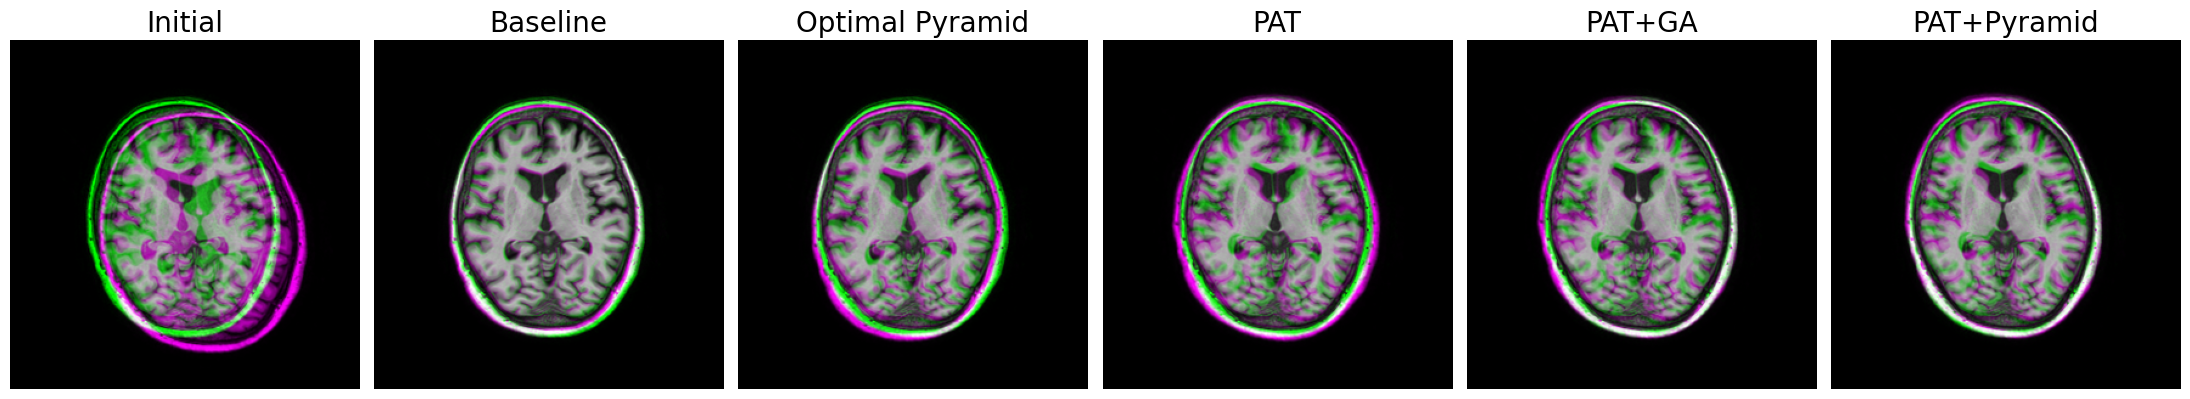

In [11]:
def show_visual_comparison(fixed,moving,results):

    diff_before   = color_overlay(fixed,moving)
    diff_A   = color_overlay(fixed, results[0])
    diff_B   = color_overlay(fixed, results[1])
    diff_C   = color_overlay(fixed, results[2]) 
    diff_D   = color_overlay(fixed, results[3]) 
    diff_E   = color_overlay(fixed, results[4]) 

    fig, axes = plt.subplots(1, 6, figsize=(22, 10))

    imgs   = [diff_before, diff_A, diff_B, diff_C, diff_D, diff_E]
    titles = ['Initial', 'Baseline', 'Optimal Pyramid', 'PAT', 'PAT+GA', 'PAT+Pyramid']
    for c, (img, title) in enumerate(zip(imgs, titles)):
        axes[c].imshow(img, cmap='gray')
        axes[c].set_title(title, fontsize=20)
        axes[c].axis('off')

    plt.tight_layout()
    plt.show()

show_visual_comparison(fixed,moving,results_t1)

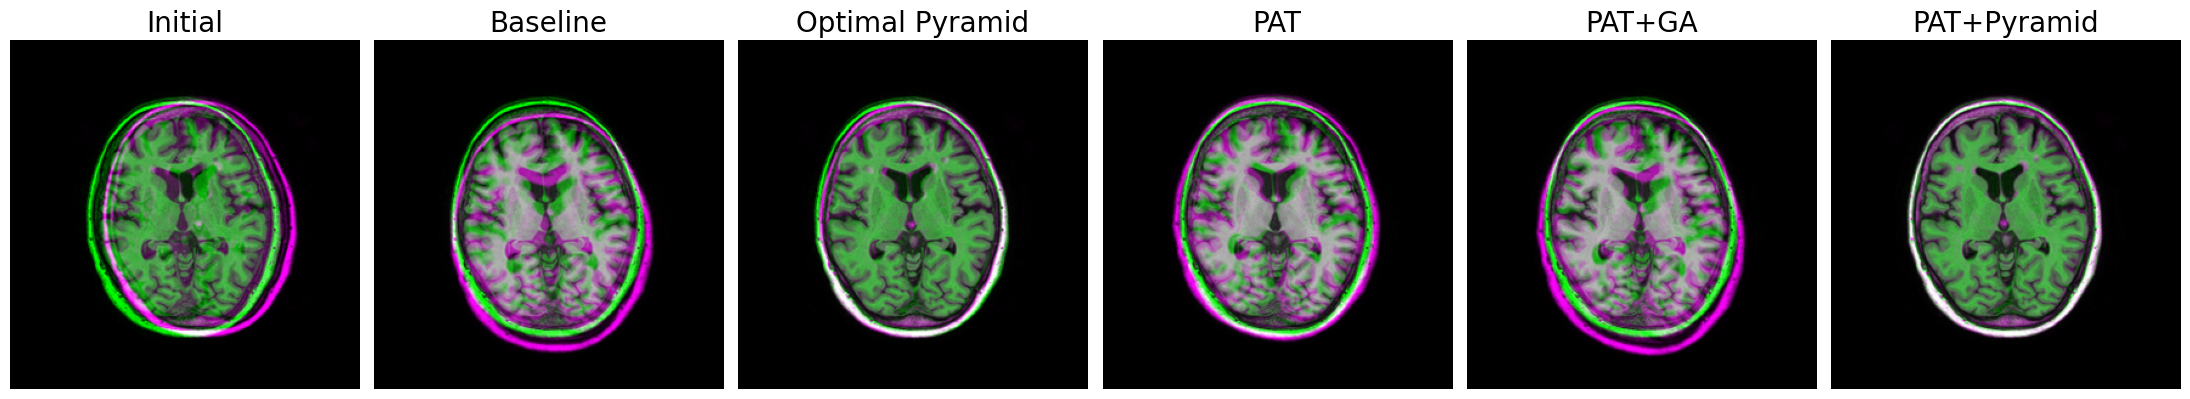

In [12]:
show_visual_comparison(fixed,moving_t2,results_t2)